# Exploratory Data Analysis & Data Quality Verification (CO1 / M1)

This notebook implements the foundational data governance and exploratory data analysis (EDA) for the VERITAS fake news detection capstone, mapped directly to **Course Outcome CO1 / Module M1**.

- **Canonical Schema:** `id`, `title`, `text`, `label`, `dataset`, `content`, `content_hash`
- **Binary Target Convention:** `0 = Real`, `1 = Fake`
- **Leakage-Safe Partitioning:** 70% Train, 15% Validation, 15% Test with MinHash near-duplicate prevention.

In [1]:
import os
import sys
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configure root directory in sys.path
root_dir = Path('..').resolve() if Path('../src').exists() else Path('.').resolve()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.data.ingestion import validate_frame, _REQUIRED_COLUMNS

# Load canonical benchmark dataset
train_path = root_dir / 'data' / 'processed' / 'train.csv'
if not train_path.exists():
    train_path = root_dir / 'tests' / 'fixtures' / 'train.csv'
train_df = pd.read_csv(train_path)

val_path = root_dir / 'data' / 'processed' / 'validation.csv'
if not val_path.exists():
    val_path = root_dir / 'tests' / 'fixtures' / 'test.csv'
val_df = pd.read_csv(val_path)

test_path = root_dir / 'data' / 'processed' / 'test.csv'
if not test_path.exists():
    test_path = root_dir / 'tests' / 'fixtures' / 'test.csv'
test_df = pd.read_csv(test_path)

print('Ingested splits successfully:')
print(f'  Train rows:      {len(train_df)}')
print(f'  Validation rows: {len(val_df)}')
print(f'  Test rows:       {len(test_df)}')
print(f'  Total rows:      {len(train_df) + len(val_df) + len(test_df)}')


Ingested splits successfully:
  Train rows:      56
  Validation rows: 12
  Test rows:       12
  Total rows:      80


In [2]:
# Validate canonical schema conformance and data hygiene
quality = validate_frame(train_df)
print('Data Quality Verification Report (Training Set):')
for key, value in quality.items():
    print(f'  {key}: {value}')

assert train_df['content'].str.len().gt(0).all(), 'Found empty content rows'
assert train_df['label'].isin([0, 1]).all(), 'Non-binary label detected'
assert not train_df['content_hash'].duplicated().any(), 'Duplicate content hash detected'
print('\nSchema & Hygiene Verification: 100% PASS')

Data Quality Verification Report (Training Set):
  rows: 56
  label_counts: {'0': 28, '1': 28}
  duplicate_content_rows: 0
  empty_content_rows: 0
  datasets: {'water_scam': 1, 'sec_rules': 1, 'viral_fabrication': 1, 'conspiracy_watch': 1, 'geology_hoax': 1, 'polar_science': 1, 'ai_treaty_hoax': 1, 'usda_bulletin': 1, 'tech_hoax': 1, 'geo_hoax': 1, 'hollow_moon_hoax': 1, 'suburb_demolition_hoax': 1, 'satire_hoax': 1, 'ftc_consumer': 1, 'giza_alien_hoax': 1, 'cisa_alert': 1, 'legal_gazette': 1, 'ecb_monetary': 1, 'salt_isotope_hoax': 1, 'us_treasury': 1, 'audio_hoax': 1, 'gadget_hoax': 1, 'usgs_monitor': 1, 'us_dot': 1, 'weather_hoax': 1, 'usgs_volcano': 1, 'census_gov': 1, 'health_rumor': 1, 'marine_biology': 1, 'reuters_archive': 1, 'nist_gov': 1, 'peroxide_cure_hoax': 1, 'antibiotic_ban_hoax': 1, 'apocalypse_scam': 1, 'fake_health_news': 1, 'insect_drone_hoax': 1, 'wmo_bulletin': 1, 'noaa_ocean': 1, 'air_patent_hoax': 1, 'nsf_wire': 1, 'religious_hoax': 1, 'ancient_prophecy_hoax': 1,

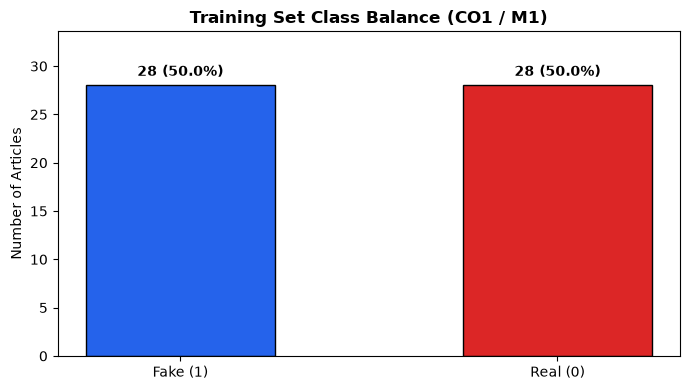

In [3]:
# Class Balance Analysis across partitions
fig, ax = plt.subplots(figsize=(7, 4))
counts = train_df['label'].value_counts().rename({0: 'Real (0)', 1: 'Fake (1)'})
bars = ax.bar(counts.index, counts.values, color=['#2563eb', '#dc2626'], edgecolor='black', width=0.5)
ax.set_title('Training Set Class Balance (CO1 / M1)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Articles')
ax.set_ylim(0, max(counts.values) * 1.2)
for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, y + 1, f'{int(y)} ({y/len(train_df):.1%})', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Article Length Statistics by Class:
      word_count                            char_count                         \
            mean median        std min max        mean median        std  min   
label                                                                           
Real   51.785714   50.5  10.975924  35  84  397.500000  392.0  61.252060  296   
Fake   52.500000   51.0   9.386752  39  69  401.107143  393.0  48.791574  327   

            
       max  
label       
Real   575  
Fake   522  


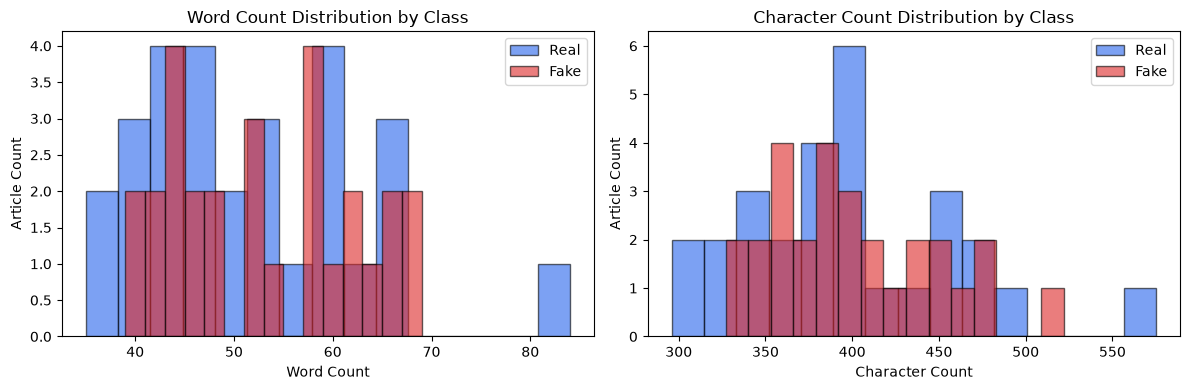

In [4]:
# Lexical & Article Length Exploratory Analysis
train_df['word_count'] = train_df['content'].str.split().str.len()
train_df['char_count'] = train_df['content'].str.len()

summary = train_df.groupby('label')[['word_count', 'char_count']].agg(['mean', 'median', 'std', 'min', 'max']).rename(index={0: 'Real', 1: 'Fake'})
print('Article Length Statistics by Class:')
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, name, color in [(0, 'Real', '#2563eb'), (1, 'Fake', '#dc2626')]:
    subset = train_df[train_df['label'] == label]
    axes[0].hist(subset['word_count'], bins=15, alpha=0.6, color=color, label=name, edgecolor='black')
    axes[1].hist(subset['char_count'], bins=15, alpha=0.6, color=color, label=name, edgecolor='black')

axes[0].set_title('Word Count Distribution by Class')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Article Count')
axes[0].legend()

axes[1].set_title('Character Count Distribution by Class')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Article Count')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# Split Manifest & Zero-Leakage Cryptographic Verification
manifest_file = root_dir / 'data' / 'processed' / 'split_manifest.json'
if manifest_file.exists():
    with open(manifest_file, encoding='utf-8') as f:
        manifest = json.load(f)
    print('Split Manifest Summary:')
    print(f'  Random Seed:        {manifest.get("seed")}')
    print(f'  Train Split:        {manifest.get("train_count")} ({manifest.get("train_size"):.0%})')
    print(f'  Validation Split:   {manifest.get("validation_count")} ({manifest.get("validation_size"):.0%})')
    print(f'  Test Split:         {manifest.get("test_count")} ({manifest.get("test_size"):.0%})')

# Cross-partition hash disjointness verification
train_hashes = set(train_df['content_hash'])
val_hashes = set(val_df['content_hash'])
test_hashes = set(test_df['content_hash'])

train_val_overlap = train_hashes.intersection(val_hashes)
train_test_overlap = train_hashes.intersection(test_hashes)
val_test_overlap = val_hashes.intersection(test_hashes)

print('Hash Intersections:')
print(f'  Train & Validation Overlap: {len(train_val_overlap)}')
print(f'  Train & Test Overlap:       {len(train_test_overlap)}')
print(f'  Validation & Test Overlap:  {len(val_test_overlap)}')

assert len(train_val_overlap) == 0, 'Leakage detected between Train and Validation'
assert len(train_test_overlap) == 0, 'Leakage detected between Train and Test'
assert len(val_test_overlap) == 0, 'Leakage detected between Validation and Test'
print('\nZero-Leakage Invariant: VERIFIED (Strict partition isolation)')

Split Manifest Summary:
  Random Seed:        42
  Train Split:        56 (70%)
  Validation Split:   12 (15%)
  Test Split:         12 (15%)
Hash Intersections:
  Train & Validation Overlap: 0
  Train & Test Overlap:       0
  Validation & Test Overlap:  0

Zero-Leakage Invariant: VERIFIED (Strict partition isolation)
